In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from biodata.delimited import DelimitedReader, DelimitedWriter
from Bio import SeqIO
from biodatatools.utils.common import json_load, json_dump
import itertools
import sys
from pathlib import Path
import pybedtools
from collections import defaultdict, Counter
from scipy.stats import fisher_exact
from biodata.bed import BEDXReader
from genomictools import GenomicCollection
import biodataplot.metaplot as bpm
from biodata.bigwig import BigWigIReader
import biodataplot.genomeview as gv
import biodataplot.utils as bpu
import matplotlib.lines as mlines
import subprocess

In [2]:
matplotlib.font_manager.fontManager.addfont(f"{Path.cwd().parent}/font/Arial.ttf")
matplotlib.rcParams["font.family"] = "Arial"
bfontsize = 12
sfontsize = 9
lw = 0.8

In [3]:
sys.path.append(f"{Path.cwd().parent}")
import utils

In [4]:
PROJECT_DIR_s = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/"
PROJECT_DIR_d = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/PROcap/"
PROJECT_DIR_r = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/"
PROJECT_DIR_o = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/"

In [5]:
sys.path.append(f"{PROJECT_DIR_s}procapnet/2_train_models/")
from data_loading import one_hot_encode
sys.path.append(f"{PROJECT_DIR_s}procapnet/5_modisco/")
from modiscolite_utils import load_modisco_results

# Get motif positions

In [6]:
s = "HEK293T"
factor = "ZNF143"
ks = ["pl", "mn"]
ps = ["divergent", "unidirectional"]
ds = ["distal", "proximal"]
gs = [f"{p}_{d}" for p, d in itertools.product(ps, ds)]
types = ["wt", "mt"]
ts = ["minTSS", "maxTSS"]

## Get motif patterns

In [7]:
modisco_results = load_modisco_results(f"{PROJECT_DIR_o}procapnet/modisco_out/{s}/strand_merged_umap/merged/counts_modisco_results.hd5")
pattern = modisco_results["pos_patterns"]["pattern_8"]
pwm = pattern["sequence"][:]
complement_order = [3, 2, 1, 0]
pwm = pwm[:, complement_order][::-1, :]
pwm_ic = pwm * utils.compute_per_position_ic(pwm)[:, None]
start, end = utils.trim_motif_by_thresh(pwm_ic)
pwm_trim = pwm[start:end]

In [8]:
# Get ZNF143 motif pattern from JASPAR "data_preprocessing/2.Other_resource.ipynb"
# Get PWM of THAP11-ZNF143 composite motif from tfmodisco

motif_file = f"{PROJECT_DIR_r}other/JASPAR/JASPAR2024_CORE_vertebrates_{factor}.txt"
with open(motif_file, "r") as fr:
	lines = fr.readlines()
	
new_lines = ['MOTIF ProCapNet THAP11-ZNF143\n',
			 F'letter-probability matrix: alength= 4 w= {len(pwm_trim)} \n',
			]
for row in pwm_trim:
	row[-1] = 1-np.sum(row[:-1])
	vs = "\t".join([f"{v:.6f}" for v in row])
	new_lines.append(f" {vs}\n")
new_lines.append('\n')
lines.extend(new_lines)

with open(motif_file, "w") as fw:
	for line in lines:
		fw.write(line)

In [9]:
%matplotlib inline

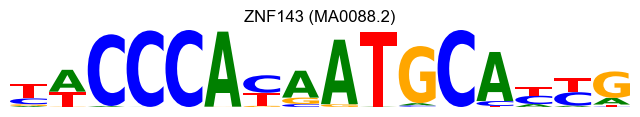

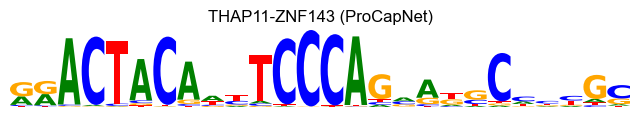

In [10]:
# Need to align the patterns on the core motif

pwms = utils.read_meme(motif_file)
titles = ["ZNF143 (MA0088.2)", "THAP11-ZNF143 (ProCapNet)"]
for motif in pwms:
	fig, ax = plt.subplots(figsize=(8,1))
	n = list(pwms).index(motif)
	pwm_ic = pwms[motif] * utils.compute_per_position_ic(pwms[motif])[:, None]
	utils.plot_motif_on_ax(pwm_ic, ax, titles[n])	

## Run FIMO

In [11]:
inputfile = f"{PROJECT_DIR_r}genomes/human/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta"
with open(inputfile, "r") as f:
	fdict = SeqIO.to_dict(SeqIO.parse(f, "fasta"))

In [12]:
def get_sequence_for_prediction(inputfiles, fdict, outputfile):
	with DelimitedWriter(outputfile) as dw:
		for inputfile in inputfiles:
			with DelimitedReader(inputfile) as dr:
				for cols in dr:
					chrom, start, end = cols[:3]
					dw.write([">" + "_".join([chrom, start, end])])
					seq = fdict[chrom][int(start):int(end)].seq.upper()
					dw.write([seq])

In [13]:
inputfiles = [f"{PROJECT_DIR_d}bed_plot/{s}_{g}.bed" for g in gs]
outputfile = f"{PROJECT_DIR_o}FIMO/{s}_seqs.fa"
get_sequence_for_prediction(inputfiles, fdict, outputfile)

In [14]:
def get_motifs(motif_file, seq_file, outputfile):
	commands = [f"{PROJECT_DIR_s}meme-5.5.7/src/fimo", 
				 "--skip-matched-sequence",
				 "--verbosity 1",
				 motif_file, 
				 seq_file,
				 ">", outputfile
				 ]
	subprocess.run(" ".join(commands), shell=True)

In [15]:
# By default the program reports all motif occurrences with a p-value less than 1e-4. 

seq_file = f"{PROJECT_DIR_o}FIMO/{s}_seqs.fa"
outputfile = f"{PROJECT_DIR_o}FIMO/{s}_predictions.txt"
get_motifs(motif_file, seq_file, outputfile)

In [16]:
df_fimo = pd.read_table(f"{PROJECT_DIR_o}FIMO/{s}_predictions.txt")
df_fimo.head(2)

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,MA0088.2,ZNF143,chr1_916612_917113,66,81,+,0.155172,0.000091,NaN,NaN
1,MA0088.2,ZNF143,chr1_1954763_1955264,97,112,-,7.465520,0.000014,NaN,NaN


In [17]:
# For each element, keep the motif with the smallest p-value

motifs = {}
for e, group in df_fimo.groupby("sequence_name"):
	top_row = group.sort_values(by="p-value").iloc[0]
	start = int(e.split("_")[1])
	mstart, mend = int(top_row["start"]), int(top_row["stop"])
	strand = top_row["strand"]
	if (mstart + mend) % 2 == 0:
		center = start + (mstart + mend) // 2 - 1
	else:
		center = start + (mstart + mend) // 2 - 1 if strand == "+" else start + (mstart + mend) // 2
	# motif center (0-based), start (0-based, included), end (0-based, not included)
	motifs[e] = [center, start + mstart - 1, start + mend, strand, top_row["motif_alt_id"]]
len(motifs)

7135

In [18]:
binding_labels = {}
b1 = pybedtools.BedTool(f"{PROJECT_DIR_r}other/GSE266489/GSE266489_antiZNF143_ChIP2_summits.bed.gz")
for g in gs:
	b2 = pybedtools.BedTool(f"{PROJECT_DIR_d}bed_plot/{s}_{g}.bed")
	overlaps = set(["_".join(i.fields[:3]) for i in b2.intersect(b1, u=True)])
	for i in b2:
		e = "_".join(i.fields[:3])
		# Motif + ChIP-seq
		binding_labels[e] = f"{factor} binding" if e in overlaps & set(motifs) else f"No {factor} binding"

In [19]:
# Criteria for elements with ZNF143 binding
# 1. Motif prediction (FIMO)
# 2. ZNF143 ChIP-seq

motifs_filtered = {}
for e in motifs:
	if binding_labels[e] == f"{factor} binding":
		motifs_filtered[e] = motifs[e]

In [20]:
json_dump(f"{PROJECT_DIR_o}labels/{s}_{factor}_ChIP.json", binding_labels)

In [21]:
Counter([motifs_filtered[e][-1] for e in motifs_filtered])

Counter({'THAP11-ZNF143': 1654, 'ZNF143': 470})

In [22]:
DE_labels = json_load(f"{PROJECT_DIR_o}labels/{s}_{factor}_DE.json")
DE_labels_all = defaultdict(set)
all_es = set(DE_labels["minTSS"]) | set(DE_labels["maxTSS"])
for e in all_es:
	unchanged = True
	for k in DE_labels:
		if e in DE_labels[k] and DE_labels[k][e] != "Unchanged":
			unchanged = False
	if unchanged:
		DE_labels_all["Non-DE"].add(e)
	else:
		DE_labels_all["DE"].add(e)

In [23]:
# Motif enrichment in DE elements

results = []
n1 = len(DE_labels_all["DE"] & set(motifs_filtered))
n2 = len(DE_labels_all["DE"]) - n1
n3 = len(DE_labels_all["Non-DE"] & set(motifs_filtered))
n4 = len(DE_labels_all["Non-DE"]) - n3
# No. DE elements with motif, OR, pvalue
n1, (n1/n2)/(n3/n4), fisher_exact([[n1,n2],[n3,n4]]).pvalue

(327, 23.151729698171607, 1.701654149033968e-205)

In [24]:
json_dump(f"{PROJECT_DIR_o}FIMO/{s}_{factor}_pos.json", motifs_filtered)

# Examples

In [25]:
outputfile = f"{PROJECT_DIR_o}temp/{s}_{factor}_pos_all.bed"
with DelimitedWriter(outputfile) as dw:
	for e in motifs_filtered:
		chrom = e.split("_")[0]
		start, end = motifs_filtered[e][1:3]
		dw.write([chrom, start, end])

In [26]:
def plot_example(region, color, outputfile, show_ylabel=True):
	data = {}
	for m in rpms:
		data[f"PRO-cap ({m})"] = rpms[m]
	data[f"{factor} ChIP (UT)"] = f"{PROJECT_DIR_r}other/GSE266489/GSE266489_antiZNF143-control_merged_normalized.bigWig"
	data[f"{factor} ChIP (T)"] = f"{PROJECT_DIR_r}other/GSE266489/GSE266489_antiZNF143-dTAG_merged_normalized.bigWig"
	data[f"{factor} motif"] = f"{PROJECT_DIR_o}temp/{s}_{factor}_pos_all.bed"
	
	formatters = {
			f"{factor} ChIP (UT)": {"plot_kw": {"fill_kw":{"color":color}}},
			f"{factor} ChIP (T)": {"plot_kw": {"fill_kw":{"color":color}}},
			f"{factor} motif": {"plot_kw": {"facecolor":color}, "anno_vspace": 0}
			}
	height_ratios = {}
	for k in data:
		if "PRO-cap" in k:
			pcolor, ncolor = ("#fb9a99", "#a6cee3") if "(UT" in k else ("#a50f15", "#08519c")
			formatters[k] = {"yscale":"asym_pos_neg", "plot_kw":{"width":3}, "pcolor":pcolor, "ncolor":ncolor}
			height_ratios[k] = 8
		elif "ChIP" in k:
			height_ratios[k] = 5
		else:
			height_ratios[k] = 3
	
	fig = gv.plot_genome_view(
		region,
		data = data,
		formatters = formatters,
		height_ratios = height_ratios,
		group_autoscales = [[k for k in data if "PRO-cap" in k],
							[k for k in data if "ChIP" in k]
						   ],
		coordinate_kw = {"major_coordinate_unit":300}
		)
	
	bpu.plt_change_figure_properties(
		fig,
		**{"fig_prop": {"size_inches":[2.17, 3.1]},
		"xticklabels_prop": {"fontsize":sfontsize},
		"yticklabels_prop": {"fontsize":sfontsize},
		"ylabel_prop": {"fontsize":bfontsize},
		"xlabel_prop": {"fontsize":bfontsize}
		},
		title_prop = {"text": ""}
		)

	bpu.plt_change_figure_properties(
		fig, 
		ax_targets=[-1],
		xlabel_prop={"text":f"Genomic position ({region.split(':')[0]})"}
		)
	if not show_ylabel:
		for i in range(len(data)):
			bpu.plt_change_figure_properties(
			fig, 
			ax_targets=[i],
			ylabel_prop={"text":""}
			)

	else:
		for i in range(len(data)):
			fig.axes[i].yaxis.set_label_coords(-0.3, 0.5)
			fig.axes[i].yaxis.set_major_formatter(lambda s, pos: f"{s:.0f}")

		x1, x2 = -0.87, -0.82
		row1, row2 = [0,6]
		y_center = (fig.axes[row1].get_position().y0 + fig.axes[row2].get_position().y1) / 2
		fig.text(x1, y_center+0.05, "HEK293T ZNF143 degron", va="center", ha="center", rotation="vertical", 
				 fontsize=bfontsize)
		line = mlines.Line2D([x2, x2], [fig.axes[row1].get_position().y1, fig.axes[row2].get_position().y0],
							 transform=fig.transFigure, color="#000000", linewidth=0.8, zorder=10)
		fig.add_artist(line)

	fig.savefig(outputfile, bbox_inches="tight", transparent=True)

In [27]:
rpms = {"UT, rep1": [f"{PROJECT_DIR_d}Alignments/{factor}_U1_5{k}_rpm.bw" for k in ks],
	   "UT, rep2": [f"{PROJECT_DIR_d}Alignments/{factor}_U2_5{k}_rpm.bw" for k in ks],
	   "T, rep1": [f"{PROJECT_DIR_d}Alignments/{factor}_T1_5{k}_rpm.bw" for k in ks],
	   "T, rep2": [f"{PROJECT_DIR_d}Alignments/{factor}_T2_5{k}_rpm.bw" for k in ks],
		}

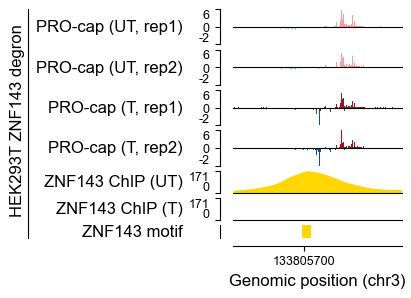

In [28]:
# Upregulation

region = "chr3:133805489-133805990"
color = "#FFD700"
outputfile = f"{PROJECT_DIR_o}figures/Fig5c_left.pdf"
plot_example(region, color, outputfile)

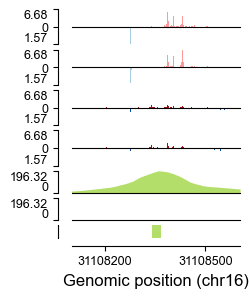

In [29]:
# Downregulation

region = "chr16:31108102-31108603"
color = "#b3de69"
outputfile = f"{PROJECT_DIR_o}figures/Fig5c_right.pdf"
plot_example(region, color, outputfile, False)

# Metaplots

In [30]:
# Get elements centered on motifs

mapping = {}
for g in gs:
	inputfile = f"{PROJECT_DIR_d}bed_plot/{s}_{g}.bed"
	outputfile = f"{PROJECT_DIR_d}bed_plot/{s}_{g}_{factor}.bed"
	with DelimitedWriter(outputfile) as dw:
		with DelimitedReader(inputfile) as dr:
			for cols in dr:
				chrom, start, end = cols[:3]
				e = "_".join([chrom, start, end])
				if e in motifs_filtered:
					center, strand, motif_pattern = motifs_filtered[e][0], motifs_filtered[e][-2], motifs_filtered[e][-1]
					# This is a composite motif of THAP11-ZNF143; align them at ZNF143 core motif
					if motif_pattern == "THAP11-ZNF143":
						center = center + 4 if strand == "+" else center - 4
					dw.write([chrom, center-250, center+250] + cols[3:])
					mapping[(chrom, center-250, center+250)] = e

In [31]:
# "*5pl_rpm.bw": positive values
# "*5mn_rpm.bw": negative values

bws = {f"{factor}_U_pl": f"{PROJECT_DIR_d}Alignments/{factor}_U_5pl_rpm.bw",
	   f"{factor}_U_mn": f"{PROJECT_DIR_d}Alignments/{factor}_U_5mn_rpm.bw",
	   f"{factor}_T_pl": f"{PROJECT_DIR_d}Alignments/{factor}_T_5pl_rpm.bw",
	   f"{factor}_T_mn": f"{PROJECT_DIR_d}Alignments/{factor}_T_5mn_rpm.bw",
	  }

In [32]:
df_features = {}
use_strand = True
for g in gs:
	bed = f"{PROJECT_DIR_d}bed_plot/{s}_{g}_{factor}.bed"
	all_regions = BEDXReader.read_all(GenomicCollection, bed, strandfield="f7")
	for k in ks:
		k2 = "+" if k == "pl" else "-"
		regions = list(filter(lambda a: a.stranded_genomic_pos.strand==k2, all_regions))
		index = [mapping[(r.chrom, r.chromStart, r.chromEnd)] for r in regions]
		for m in bws:
			# Change the sign: maxTSS - positive values; minTSS - negative values
			sign = 1 if k2 == "+" else -1
			df_features[(m,g,k2)] = sign*pd.DataFrame(bpm.generate_signal_profile(regions, BigWigIReader(bws[m]), fixed_size=501, use_strand=use_strand), index=index)

In [33]:
# 10-bp bins

df_bins = defaultdict(dict)
for k in df_features:
	df_bins[k] = utils.bin_values(df_features[k])

In [34]:
df_reformat = defaultdict(dict)
for k in df_bins:
	df = df_bins[k].reset_index()
	df_reformat[k] = pd.melt(df,
							  id_vars="index",
							  value_vars=list(df.columns[1:]),
							  var_name="Position",
							  value_name="Feature"
							  )

In [35]:
# Source data for Fig. 5d

df_metaplots = {}
labels = ["Up", "Down"]
for d, t, label in itertools.product(ds, ts, labels):
	dfs = []
	for p in ps:
		if t == "minTSS":
			df1 = pd.concat([df_reformat[(f"{factor}_U_pl", f"{p}_{d}", "-")], 
							df_reformat[(f"{factor}_U_mn", f"{p}_{d}", "+")]])
			df2 = pd.concat([df_reformat[(f"{factor}_T_pl", f"{p}_{d}", "-")], 
							df_reformat[(f"{factor}_T_mn", f"{p}_{d}", "+")]])
		else:
			df1 = pd.concat([df_reformat[(f"{factor}_U_pl", f"{p}_{d}", "+")], 
							df_reformat[(f"{factor}_U_mn", f"{p}_{d}", "-")]])
			df2 = pd.concat([df_reformat[(f"{factor}_T_pl", f"{p}_{d}", "+")], 
							df_reformat[(f"{factor}_T_mn", f"{p}_{d}", "-")]])

		filtered_df1 = df1[df1["index"].isin([k for k, v in DE_labels[t].items() if v == label])].copy()
		filtered_df1["Label"] = f"{t} (UT)"
		filtered_df2 = df2[df2["index"].isin([k for k, v in DE_labels[t].items() if v == label])].copy()
		filtered_df2["Label"] = f"{t} (T)"
		dfs.extend([filtered_df1, filtered_df2])
	df_metaplots[(d,t,label)] = pd.concat(dfs).reset_index(drop=True)	
	if d == "proximal" and ((t == "minTSS" and label == "Up") or (t == "maxTSS" and label == "Down")):
		df_metaplots[(d,t,label)].to_csv(f"{PROJECT_DIR_o}source_data/Fig5d/{d}_{t}_{label}.txt", sep="\t", index=False)

In [36]:
for d, t in itertools.product(ds, ts):
	maxs = []
	mins = []
	labels2 = [f"{t} (UT)", f"{t} (T)"]
	for l1, l2 in itertools.product(labels, labels2):
		df = df_metaplots[(d,t,l1)]
		maxs.append(df[df["Label"]==l2].groupby("Position")["Feature"].mean().max())
		mins.append(df[df["Label"]==l2].groupby("Position")["Feature"].mean().min())
	print(d, t, max(maxs), min(mins))

distal minTSS 0.0 -7.920089080663664
distal maxTSS 2.734872468933463 0.0
proximal minTSS -0.0044603606331206505 -2.0348753707394716
proximal maxTSS 5.508279745708461 0.0


In [37]:
def generate_metaplot(d, t, labels, df_metaplots, ylims, yticks=None, xlabel="Distance (bp)", test=False):
	fig, axes = plt.subplots(1,len(labels),figsize=(5.7,1.5))
	labelpad = 2
	y_align = -0.3
	wspace = 0.3
	
	hue_order = [f"{t} (UT)", f"{t} (T)"]
	palette = ["#a6cee3", "#08519c"] if t == "minTSS" else ["#fb9a99", "#a50f15"]
	
	for label in labels:
		col = labels.index(label)
		ax = axes[col]
		df = df_metaplots[(d,t,label)]
		utils.generate_feature_metaplot(df, palette, hue_order, ax, test, "se")

		ax.spines[["right", "top"]].set_visible(False)
		ax.spines['left'].set_position(('outward', 10))
		ax.spines['bottom'].set_position(('outward', 10))

		tot = len(set(df["index"]))
		ax.set_title(f"{label} (n={tot})", fontsize=bfontsize, pad=labelpad+5)
		if col == 1:
			anchor = (0.45,0.4) if t == "minTSS" else (0.45,1.05)
			ax.legend(loc="upper left", bbox_to_anchor=anchor, fontsize=sfontsize)
		else:
			ax.legend([],[], frameon=False)
	
		ax.set_ylim(ylims)
		if yticks:
			ax.set_yticks(yticks)
			ax.set_yticklabels([str(y) for y in yticks])
		if col == 0:
			ax.set_ylabel("PRO-cap", fontsize=bfontsize)
			ax.yaxis.set_label_coords(y_align, 0.5)
		else:
			ax.set_ylabel("")
			ax.set_yticklabels([])
		
		xticklabel_list = ["-200", "", "", "", "0", "", "", "", "200"]
		xtick_list = [4+n*5 for n in range(9)]
		ax.set_xlim([0,48])
		ax.set_xticks(xtick_list)
		ax.set_xticklabels(xticklabel_list)
		ax.set_xlabel(xlabel, fontsize=bfontsize)
		
		ax.tick_params(labelsize=sfontsize)

		ax.axhline(y=0, color="#bdbdbd", ls="--", lw=lw)
		ax.axvline(x=25, ymin=-0.1, ymax=1, color="#bdbdbd", ls="--", lw=lw, clip_on=False, zorder=1)
		
	fig.subplots_adjust(wspace=wspace)

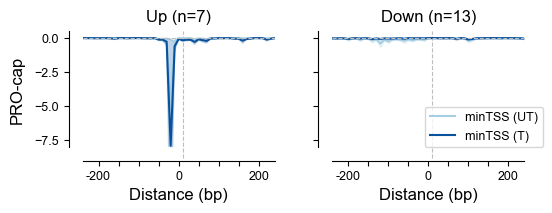

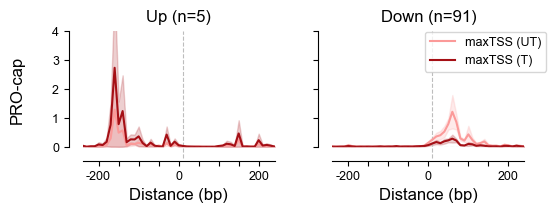

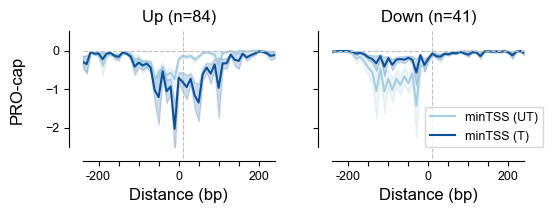

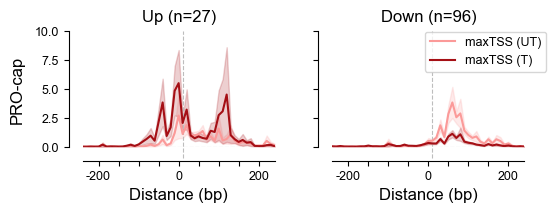

In [38]:
for d, t in itertools.product(ds, ts):
	if d == "distal":
		ylims = [-8, 0.5] if t == "minTSS" else [0, 4]
	else:
		ylims = [-2.5, 0.5] if t == "minTSS" else [0, 10]
	generate_metaplot(d, t, labels, df_metaplots, ylims)

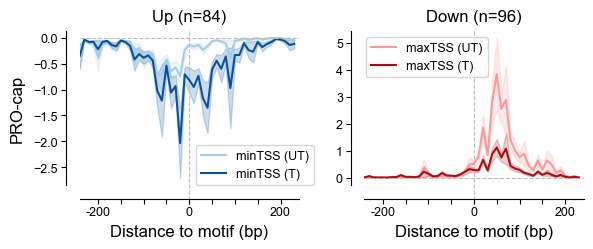

In [39]:
fig, axes = plt.subplots(1,2,figsize=(6.5,2))

d = "proximal"
labelpad = 2
test = False
for col, t in enumerate(ts):
	ax = axes[col]
	hue_order = [f"{t} (UT)", f"{t} (T)"]
	palette = ["#a6cee3", "#08519c"] if t == "minTSS" else ["#fb9a99", "#a50f15"]
	label = "Up" if t == "minTSS" else "Down"
	
	df = df_metaplots[(d,t,label)]
	utils.generate_feature_metaplot(df, palette, hue_order, ax, test, "se")

	ax.spines[["right", "top"]].set_visible(False)
	ax.spines['left'].set_position(('outward', 10))
	ax.spines['bottom'].set_position(('outward', 10))

	tot = len(set(df["index"]))
	ax.set_title(f"{label} (n={tot})", fontsize=bfontsize, pad=labelpad+5)
	anchor = (0.5,0.3) if t == "minTSS" else (-0.02,1)
	ax.legend(loc="upper left", bbox_to_anchor=anchor, fontsize=sfontsize)

	if col == 0:
		ax.set_ylabel("PRO-cap", fontsize=bfontsize)
		ax.yaxis.set_label_coords(-0.25, 0.5)
	else:
		ax.set_ylabel("")
	xticklabel_list = ["-200", "", "", "", "0", "", "", "", "200"]
	xtick_list = [n*5 for n in range(1,10)]
	ax.set_xlim([1,49])
	ax.set_xticks(xtick_list)
	ax.set_xticklabels(xticklabel_list)
	ax.set_xlabel("Distance to motif (bp)", fontsize=bfontsize)
	
	ax.tick_params(labelsize=sfontsize, pad=labelpad)

	ax.axhline(y=0, color="#bdbdbd", ls="--", lw=lw)
	ax.axvline(x=25, ymin=-0.1, ymax=1, color="#bdbdbd", ls="--", lw=lw, clip_on=False, zorder=1)

fig.subplots_adjust(wspace=0.3)
plt.savefig(f"{PROJECT_DIR_o}figures/Fig5d.pdf", bbox_inches="tight", transparent=True) 